# Ejercicio 06 · VAE, evaluación y Model Card

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Unidad III

Integra LAB10 sobre el proyecto base `INF8239_U03_Generativos_Proyecto_Base`. El entrenamiento completo se ejecuta con `uv run python scripts/train_ae_vae.py` (unos 3 minutos en CPU). Este cuaderno recarga los modelos guardados, verifica que reproducen las métricas y presenta la evidencia.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Image, display

from inf8239_u03_gen.data import normalize_images, split_train_valid
from inf8239_u03_gen.evaluation import reconstruction_errors

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
REPORTS = ROOT / "reports"
metrics = json.loads((REPORTS / "metricas.json").read_text())
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## 1. Datos y partición reproducible

In [2]:
(x_all, y_all), (x_test_raw, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_test = normalize_images(x_test_raw)
train_idx, valid_idx = split_train_valid(len(x_all), seed=42)
saved = np.loadtxt(REPORTS / "indices_validacion.csv", skiprows=1, dtype=int)
assert np.array_equal(valid_idx, saved)
print(len(train_idx), "entrenamiento ·", len(valid_idx), "validación ·", len(x_test), "prueba")

54000 entrenamiento · 6000 validación · 10000 prueba


## 2. Líneas base, AE y VAE: reconstrucción en prueba

In [3]:
table = pd.read_csv(REPORTS / "reconstruccion.csv")
check = {}
ae = tf.keras.models.load_model(ROOT / "models/autoencoder.keras")
check["ae_16"] = reconstruction_errors(x_test, ae.predict(x_test, verbose=0))["mse_pixel"]
for dim in [2, 16]:
    encoder = tf.keras.models.load_model(ROOT / f"models/encoder_{dim}.keras")
    decoder = tf.keras.models.load_model(ROOT / f"models/decoder_{dim}.keras")
    mean, _ = encoder.predict(x_test, verbose=0)
    check[f"vae_{dim}"] = reconstruction_errors(x_test, decoder.predict(mean, verbose=0))["mse_pixel"]
table["mse_recargado"] = table["modelo"].map(check)
table.round(4)

,modelo,mse_pixel,bce_por_imagen,parametros,segundos,epocas,tamano_kb,perdida_valid,kl_valid,mse_recargado
0,media,0.0866,385.0186,784,0.0000,NaN,NaN,NaN,NaN,NaN
1,pca_16,0.0198,249.2796,13328,0.2275,NaN,NaN,NaN,NaN,NaN
2,ae_16,0.0179,234.5889,25888,19.8281,30.0,330.6523,NaN,NaN,0.0179
3,vae_2,0.0292,257.9558,202516,41.1984,40.0,832.9561,262.9200,6.3413,0.0292
4,vae_16,0.0140,223.9385,207920,44.1804,40.0,854.0703,242.6033,15.6437,0.0140


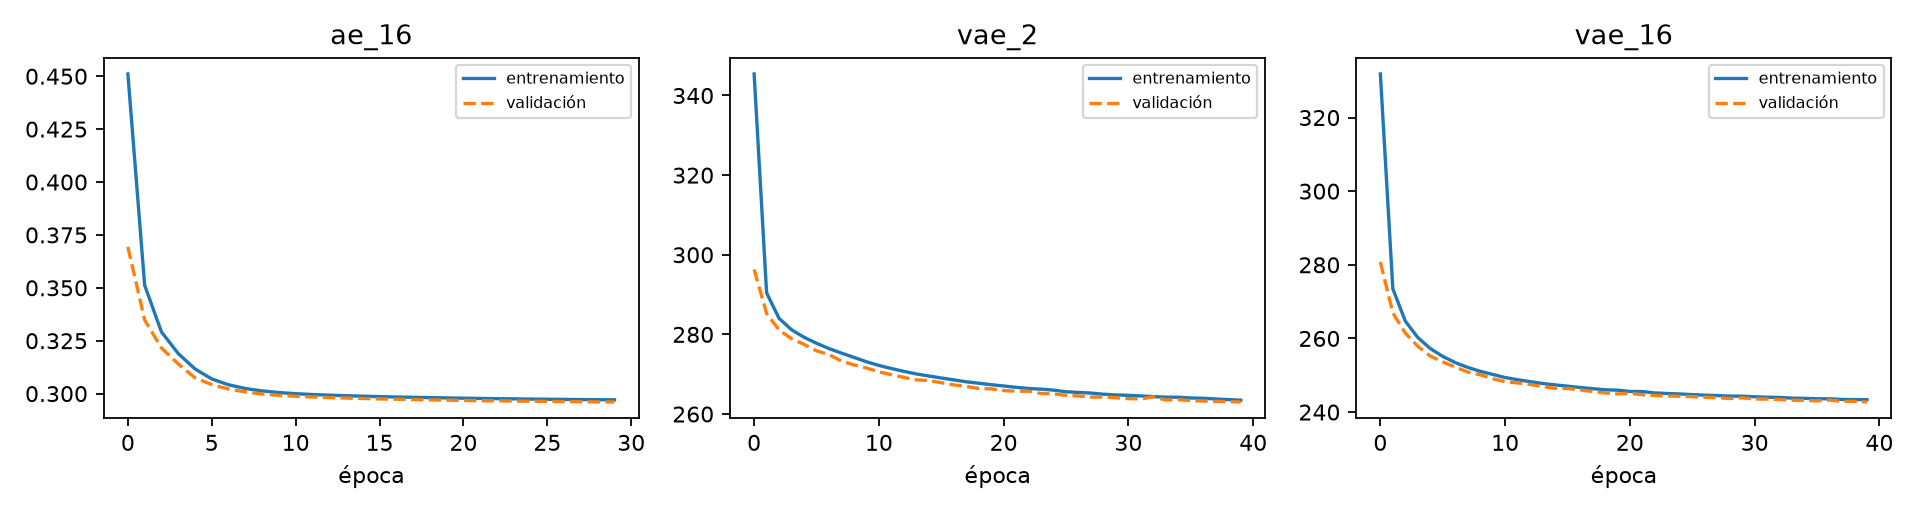

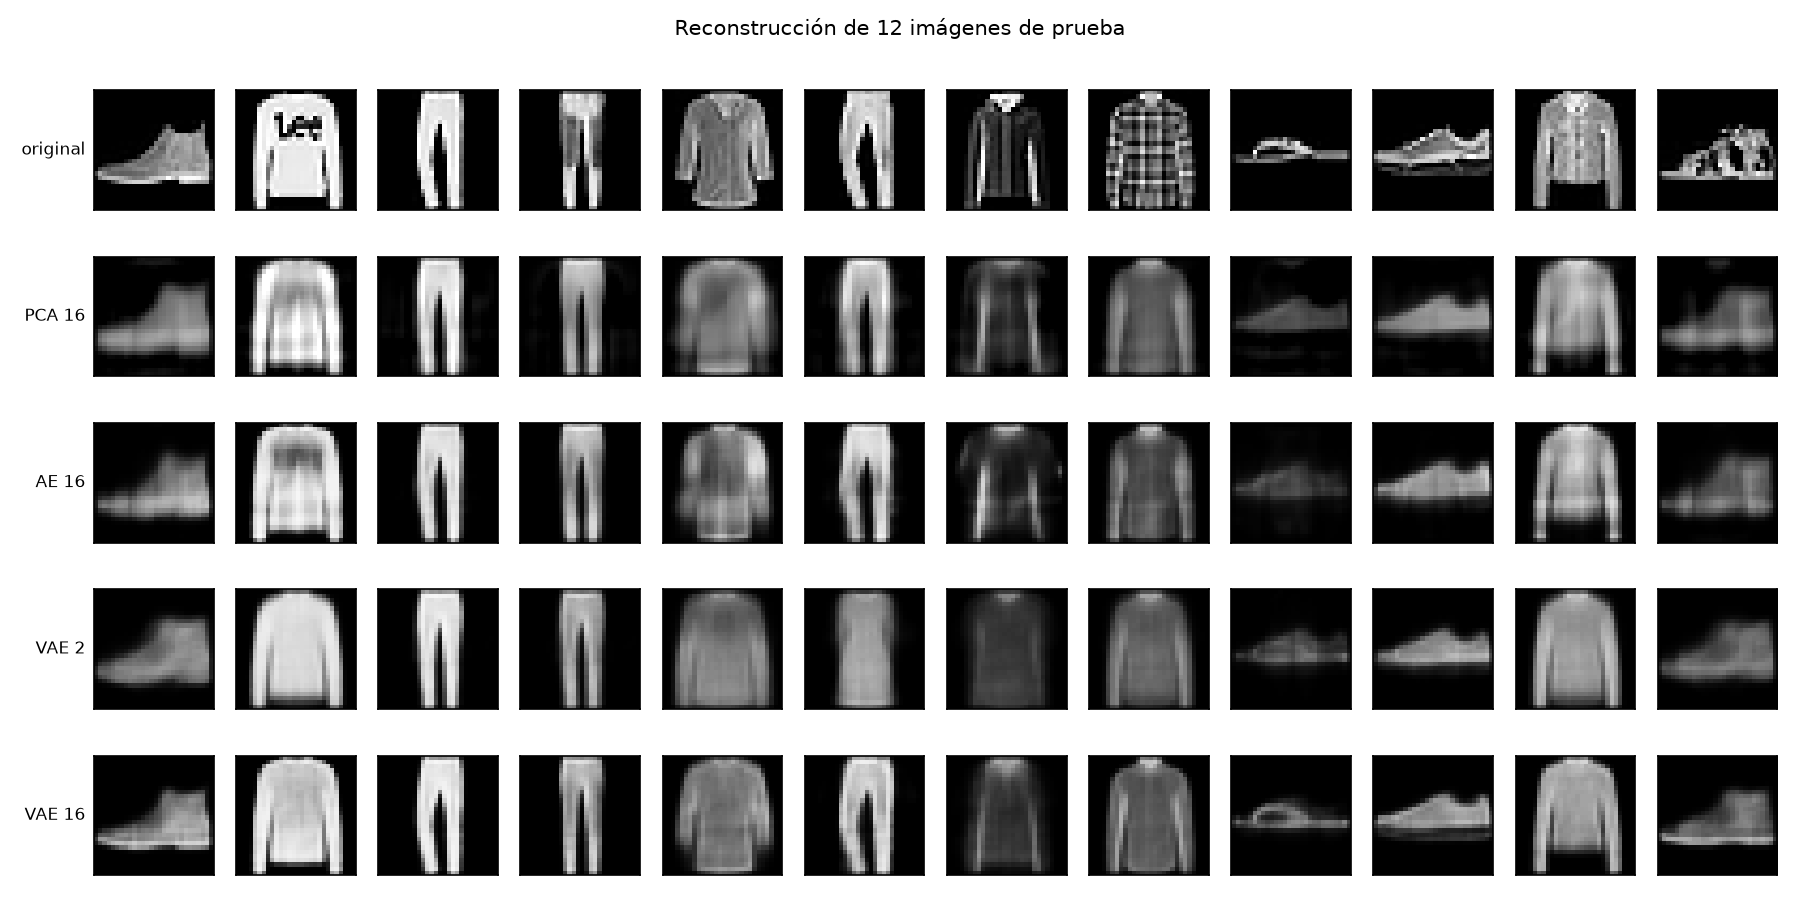

In [4]:
display(Image(filename=str(REPORTS / "curvas.png")))
Image(filename=str(REPORTS / "reconstruccion.png"))

## 3. Decisión (tomada en validación)

In [5]:
json.loads((REPORTS / 'decision.json').read_text())

{'modelo_elegido': 'vae_16',
 'razon': 'Pérdida total en validación: vae_16=242.60, vae_2=262.92. Se elige la menor: vae_16.',
 'regla': 'VAE con menor pérdida total (reconstrucción + KL) en validación',
 'tomada_antes_de_test': True}

## 4. Muestreo e interpolación

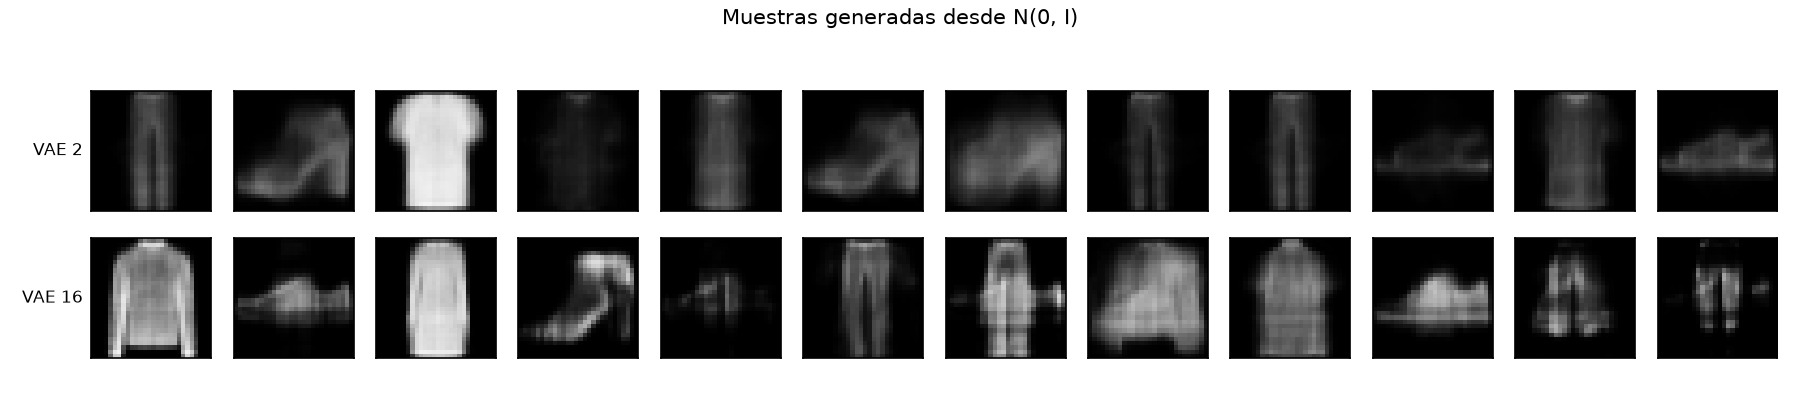

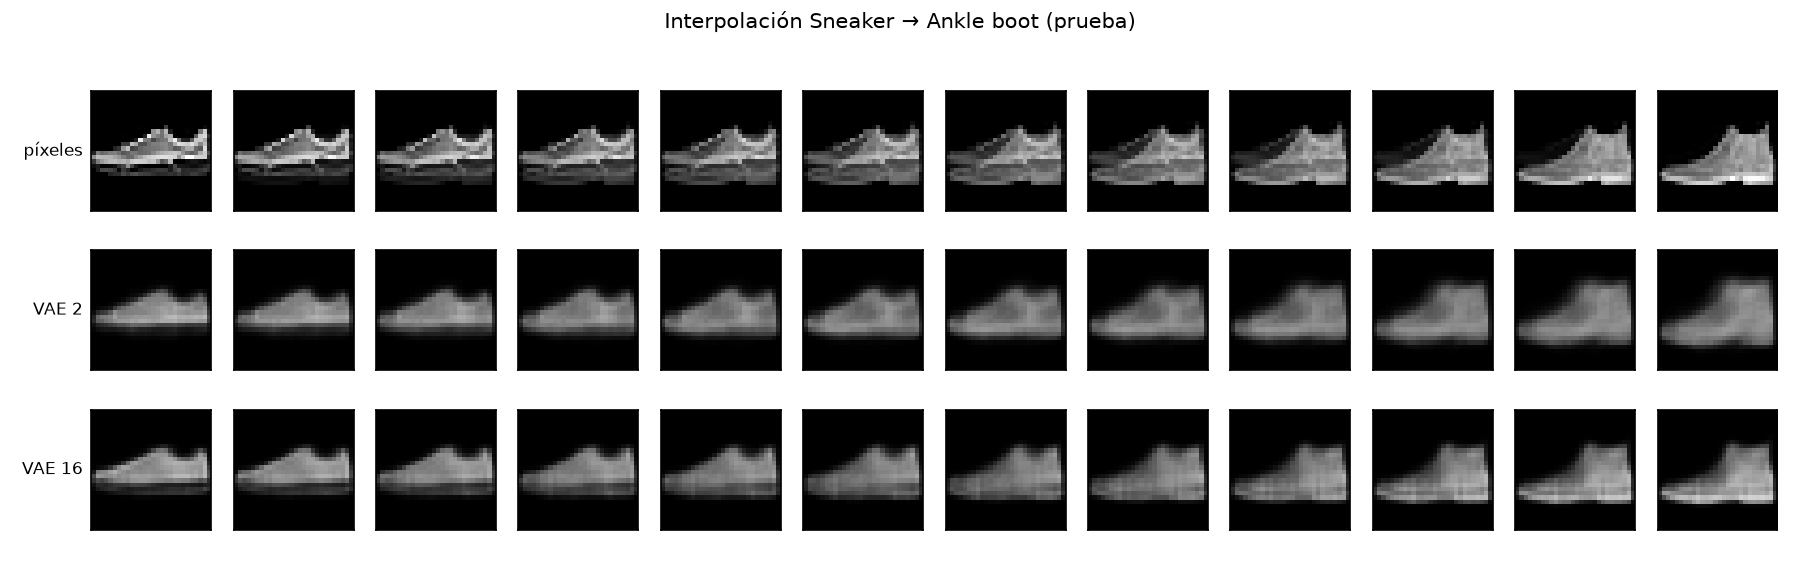

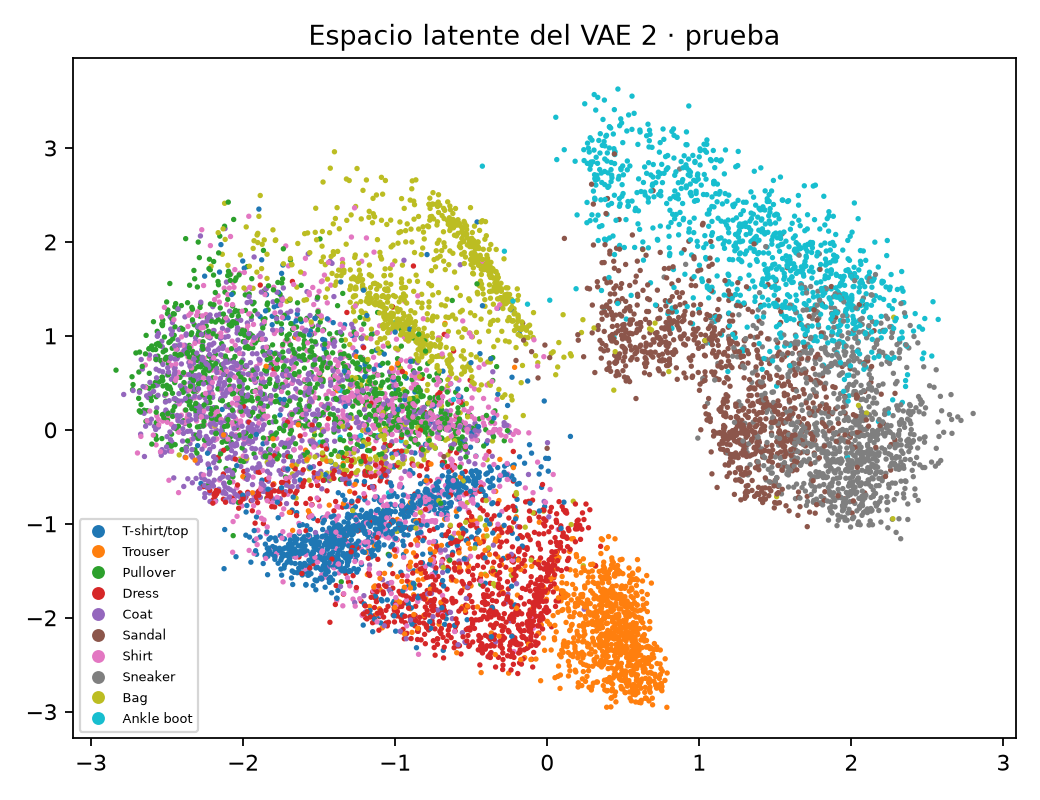

In [6]:
display(Image(filename=str(REPORTS / "muestras.png")))
display(Image(filename=str(REPORTS / "interpolacion.png")))
Image(filename=str(REPORTS / "espacio_latente.png"))

## 5. Fidelidad, diversidad y memoria

In [7]:
gen = pd.read_csv(REPORTS / "generacion.csv")
print("Exactitud del clasificador juez en prueba:", round(metrics["generacion"]["exactitud_juez_prueba"], 3))
print("Umbral de posible copia:", round(metrics["generacion"]["umbral_copia"], 3))
gen.round(3)

Exactitud del clasificador juez en prueba: 0.893
Umbral de posible copia: 1.961


,conjunto,confianza_media,confianza_mayor_0_9,clases_cubiertas,entropia_clases,dispersion,dist_vecino_train_mediana,posibles_copias
0,real_prueba,0.900,0.704,10,0.998,11.243,3.521,0.050
1,vae_2,0.528,0.092,9,0.883,6.956,2.559,0.190
2,vae_16,0.625,0.163,10,0.981,8.553,3.625,0.005


## 6. Interpretación

| | |
|---|---|
| **Observación** | El VAE 16 reconstruye mejor que todos (MSE 0.0140 frente a 0.0179 del AE y 0.0198 de PCA) y genera muestras de las 10 clases (entropía 0.98). El VAE 2 reconstruye peor que PCA y nunca genera Pullover. |
| **Evidencia** | Pérdida de validación: 242.6 (VAE 16) frente a 262.9 (VAE 2). Solo el 0.5 % de las muestras del VAE 16 queda más cerca de una imagen de entrenamiento que el 95 % de las imágenes reales. |
| **Interpretación** | Dos dimensiones no bastan para las prendas superiores, que se solapan en el espacio latente; el VAE 2 produce prototipos borrosos. El VAE 16 no memoriza, pero sus muestras siguen siendo menos nítidas que las reales (confianza del juez 0.63 frente a 0.90). |
| **Decisión** | Se usa el VAE 16. Cuesta prácticamente lo mismo que el VAE 2 (207 920 frente a 202 516 parámetros; 44 s frente a 41 s). Las muestras no deben presentarse como datos reales ni como garantía de privacidad. |